# Business and data understanding.

This notebook defines the bussines objectives, the success criteria and data exploration.

## Business understanding.

**Objective:** 
Predict the closing price of Apple (AAPL) for the next trading day.

**Success criteria:** 
Model metrics on the test set are better than the baseline.
The baseline is defined as a one day lag prediction where the next day close is same then previous closing day.
The metrics used to compare the model against the baseline are Root Mean Square Error `RMSE` and Mean Directional Accuracy `MDA`, to ensure not only the error is lower but moves in the correct direction (up/down).

| Metric | Success Criteria |
|---|---|
| `RMSE` | Model < Baseline |
| `MDA` | Model > Baseline |


## Data understanding.

The dataset includes stock prices for all companies in the S&P 500 index, the dataset is updated daily and is available at Kaggle as a public domain.

Yash. 2026. *S&P500 All Assets – Daily Updated Dataset*. Kaggle.  
https://www.kaggle.com/datasets/yash16jr/s-and-p500-daily-update-dataset/data

In this section we do an exploratory data study to discover problems early before we move to the next stage, at the same time we gain some insights to visualize what to expect from the data (i.e. how the stock price moves over time), this exploration can provide some direction on how to better prepare the data for modeling and what to expect from the model predictions.

The dataset is located at `data/SnP_daily_update.csv/`


### Setup

In [1]:
""" Notebook setup to make the project's modules importable. """

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if "TF_CPP_MIN_LOG_LEVEL" not in os.environ:
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide TensorFlow info/warning logs

In [2]:
""" Plot are defined in a plotting module for a consistent style """
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import plotting

plotting.set_plot_style()
pd.set_option("display.width", 120)


## Load the dataset.


In [3]:
""" Load the dataset from csv file """
df = pd.read_csv(config.DATA_PATH, low_memory=False)
df.head()

,Price,Close,Close.1,Close.2,Close.3,Close.4,Close.5,Close.6,Close.7,Close.8,...,Volume.493,Volume.494,Volume.495,Volume.496,Volume.497,Volume.498,Volume.499,Volume.500,Volume.501,Volume.502
0,Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,19.772951126098633,6.400959491729736,NaN,NaN,18.078800201416016,7.60190486907959,30.8563289642334,37.09000015258789,21.703716278076172,...,1832400,4741400,2670400,27809100,NaN,NaN,2962274,805872,168800,NaN
3,2010-01-05,19.55817413330078,6.4120259284973145,NaN,NaN,17.9327335357666,7.5765485763549805,31.047039031982422,37.70000076293945,21.669450759887695,...,1724500,5644300,4321400,30174700,NaN,NaN,3298757,1769643,168800,NaN
4,2010-01-06,19.488679885864258,6.31003475189209,NaN,NaN,18.032329559326172,7.543794631958008,31.37708282470703,37.619998931884766,21.628334045410156,...,2254400,2738800,2164500,35044700,NaN,NaN,4178981,1315619,385300,NaN


#### The csv file has the following structure:
- The first two rows are column headers.
    - The first column header includes `Close`, `High`, `Low`, `Open`, `Volume`.
    - The second column header includes the ticker names like `AAPL` or `AMZN`.
    - The third row is empty.
- The first column is the Date index.

To properly load this dataset we are combining the two column headers into a hierarchical index using pandas `MultiIndex` object.

Reference:
https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html

In [4]:
""" Load the dataset with hierarchical indexing """

df = pd.read_csv(
    config.DATA_PATH,
    header=[0, 1],      # first two rows are headers
    skiprows=[2],       # skip the empty third row
    index_col=0,        # first column is the Date
    parse_dates=True    # convert Date to datetime
)

print(df)


Price            Close                                                                                                 \
Ticker               A        AAPL        ABBV        ABNB         ABT       ACGL         ACN        ADBE         ADI   
2010-01-04   19.772951    6.400959         NaN         NaN   18.078800   7.601905   30.856329   37.090000   21.703716   
2010-01-05   19.558174    6.412026         NaN         NaN   17.932734   7.576549   31.047039   37.700001   21.669451   
2010-01-06   19.488680    6.310035         NaN         NaN   18.032330   7.543795   31.377083   37.619999   21.628334   
2010-01-07   19.463402    6.298369         NaN         NaN   18.181709   7.499420   31.347744   36.889999   21.457005   
2010-01-08   19.457092    6.340242         NaN         NaN   18.274660   7.484628   31.223061   36.689999   21.580359   
...                ...         ...         ...         ...         ...        ...         ...         ...         ...   
2026-09-14  146.800003  333.0799

### MultiIndex Access Quick Reference
The following table shows some ways to access data subsets using `MultiIndex':

| Goal | Code Example | Result |
|------|--------------|--------|
| Get AAPL Close | `df['Close', 'AAPL']` | Series of AAPL Close prices |
| Get all Close columns | `df['Close']` | DataFrame of Close for all tickers |
| Get all fields for AAPL | `df.xs('AAPL', level=1, axis=1)` | Close/High/Low/Open/Volume for AAPL |
| Get Close for AAPL & META | `df.loc[:, ('Close', ['AAPL', 'META'])]` | Close subset for selected tickers |
| Get all tickers for Close & High | `df[['Close', 'High']]` | Multi-field subset |
| Get AAPL + related tickers (AAPL, GOOG, MSFT) | `df.loc[:, (slice(None), ['AAPL','GOOG','MSFT'])]` | All fields for selected tickers |
| Get a date range for AAPL | `df.loc['2010-01-01':'2010-01-10', (slice(None), 'AAPL')]` | AAPL panel over date range |
| Get specific date + field | `df.loc['2010-01-04', ('Close','AAPL')]` | Single value |
| Get Close for all tickers on a date | `df.loc['2010-01-04', 'Close']` | Row of Close values |
| Get all fields for AAPL & AMZN | `df.loc[:, (slice(None), ['AAPL','AMZN'])]` | Multi-field, multi-ticker panel |


## Data Exploration.

#### To data exploration focus on Apple stiker AAPL.

In [5]:
""" Get a cross-section of the dataset with only Apple data """

apple_df = df.xs('AAPL', level=1, axis=1)
print("shape (rows, columns):", apple_df.shape)

shape (rows, columns): (4203, 5)


In [6]:
""" Get dataset information """
apple_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4203 entries, 2010-01-04 to 2026-09-18
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4203 non-null   float64
 1   High    4203 non-null   float64
 2   Low     4203 non-null   float64
 3   Open    4203 non-null   float64
 4   Volume  4203 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 197.0 KB


### Volume is a count of shares so it is an integer, the rest are real numbers representing the stock price.

## Data Quality

In [7]:
""" Verify the data quality """
checks = {
    "rows": len(apple_df),
    "missing values": int(apple_df.isna().sum().sum()),
    "duplicated dates": int(apple_df.index.duplicated().sum()),
    "zero volume days": int((apple_df["Volume"] == 0).sum()),
    "rows with High < Low": int((apple_df["High"] < apple_df["Low"]).sum()),
}
display(pd.Series(checks, name="value").to_frame())
display(apple_df[apple_df["Volume"] == 0])

# Gaps between consecutive trading days. Weekends and holidays give 3-4 calendar days;
# longer gaps can mean missing data or a market closure.
gaps = apple_df.index.to_series().diff().dt.days
print("Largest gaps between rows (calendar days):")
print(gaps.sort_values(ascending=False).head(5))

,value
rows,4203
missing values,0
duplicated dates,0
zero volume days,0
rows with High < Low,0


Price,Close,High,Low,Open,Volume


Largest gaps between rows (calendar days):
2012-10-31    5.0
2025-04-21    4.0
2021-06-01    4.0
2017-09-05    4.0
2016-03-28    4.0
dtype: float64


### The data is clean:
- No missing values.
- No duplicates.
- No zero volume days.
- No inconsistent values (High < Low).
- The longest gap was caused by hurricane Sandy on October 2012 [1]

Reference:
[1] https://www.theguardian.com/world/2012/oct/31/new-york-stock-exchange-opens-sandy


In [8]:
""" Get basic statistics from the data """
apple_df.describe()

Price,Close,High,Low,Open,Volume
count,4203.000000,4203.000000,4203.000000,4203.000000,4.203000e+03
mean,86.239713,87.099488,85.295393,86.161036,2.117998e+08
std,84.788716,85.627460,83.848298,84.680848,2.136442e+08
min,5.744145,5.862286,5.690308,5.753714,1.791060e+07
25%,18.917126,19.022925,18.697146,18.902979,7.341500e+07
50%,40.720520,40.996762,40.451919,40.748178,1.253072e+08
75%,150.410011,151.965513,148.489408,150.111728,2.791866e+08
max,339.786926,344.273097,337.059318,339.736982,1.880998e+09


#### The data shows a maximum closing stock price of $339.79 with a minimum of $5.74 since 2010, the mean is $86 with a standard deviation of $84.79 which shows how much the stock has changed in a period of 16 years.

## Full History

To get the full price history we defined a plot function `plot_price_and_volume` to get the price and volume of selected ticker in the configuration file `config`

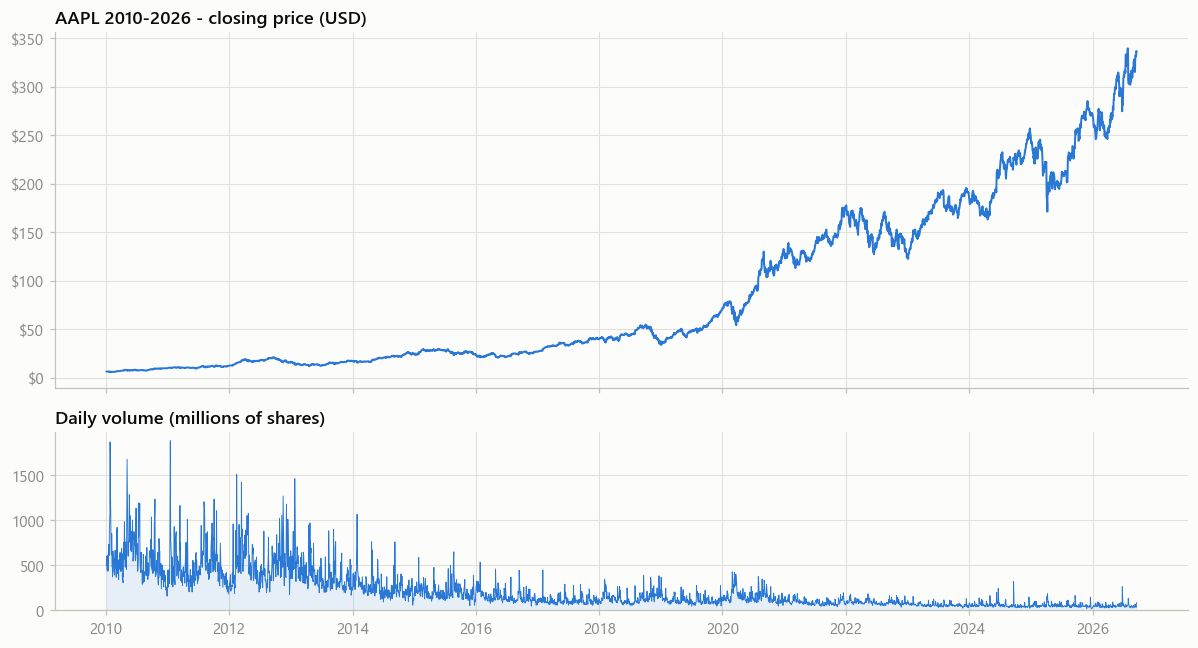

In [9]:
""" Plot the full price history """
plotting.plot_price_and_volume(apple_df, title=f"{config.TICKER} 2010-2026")
plt.show()

### The plot shows a large volume variation from 2010 to 2018 with a decreasing tendency and a steady and slow price growth before 2018, then an more pronounced price increase from $50 to $339 after 2018.

### The stock price dataset is a time series, the train test split for time series must be in chronological order to avoid data leakage, but training the model on old data when the stock price was below $50 would mean that the model would have to predict prices in ranges it has never seen during training, it would have to extrapolate wich represents a problem for neural networks, they are good at intrapolation but nos so good at extrapolation [2], a solution is to use logarithmic returns [3]

The daily **log return** is

$$r_t = \ln\left(\frac{C_t}{C_{t-1}}\right) \approx \text{percentage change for small moves}$$

Where:

$C_t =$ current closing price

$C_{t-1}$ = previous closing price

References:

[2] lsusr. "The Extrapolation Problem." *LessWrong*, October 10, 2021. https://www.lesswrong.com/posts/ASxdfSKTbcEy6MCr3/the-extrapolation-problem.

[3] Shai, Motty, Simple Return vs. Logarithmic Return – Additional Aspects (March 02, 2025). Available at SSRN: https://ssrn.com/abstract=5161959

### The `add_features` function in `src/features.py` implements the log return formula and adds the resulting column to the dataset.

In [10]:
""" Get a summary of the dataset using log returns """

from src.features import add_features

data = add_features(apple_df)
returns = data["log_return"].dropna()

summary = pd.Series({
    "first close ($)": apple_df["Close"].iloc[0],
    "last close ($)": apple_df["Close"].iloc[-1],
    "growth (x)": apple_df["Close"].iloc[-1] / apple_df["Close"].iloc[0],
    "mean daily return (%)": returns.mean() * 100,
    "std of daily return (%)": returns.std() * 100,
    "annualized volatility (%)": returns.std() * np.sqrt(252) * 100,
    "share of up days (%)": (returns > 0).mean() * 100,
    "skewness": returns.skew(),
    "excess kurtosis": returns.kurt(),
    "worst day (%)": (np.exp(returns.min()) - 1) * 100,
    "best day (%)": (np.exp(returns.max()) - 1) * 100,
}).round(3)
print(summary.to_frame("value"))

                             value
first close ($)              6.401
last close ($)             336.130
growth (x)                  52.512
mean daily return (%)        0.094
std of daily return (%)      1.771
annualized volatility (%)   28.112
share of up days (%)        53.070
skewness                    -0.170
excess kurtosis              6.037
worst day (%)              -12.865
best day (%)                15.329


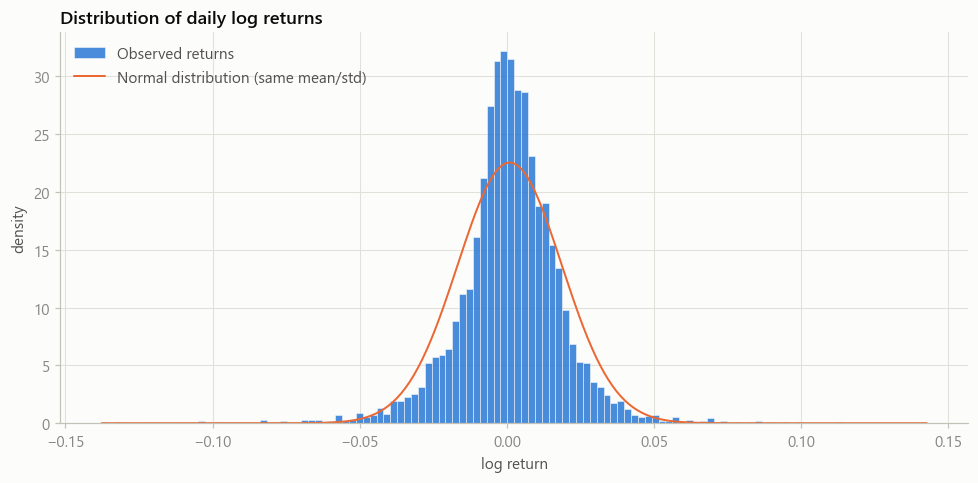

In [11]:
""" Plot the log returns distribution """
plotting.plot_return_distribution(returns)
plt.show()

### The dayly log return distribution plot toghether with the sumary reveals the following insights:
- The mean daily return is low compared with its standard deviation, so the signal is noisy.
- Excess kurtosis far above 0 means that extreme days happen far more often than a normal distribution predicts [4]. 

For the models we can use the **Huber loss** [5], which is less sensitive to extreme errors than MSE, it acts like MSE for small errors and behaves like MAE for large errors [6]. 

References:

[4] Siddiqui, Owais. "What Is Kurtosis? Fat Tails & Extreme Risk Explained." Learnsignal. October 7, 2022. Updated June 23, 2026. https://www.learnsignal.com/blog/kurtosis/.

[5] Wikipedia contributors, "Huber loss," Wikipedia, The Free Encyclopedia, https://en.wikipedia.org/w/index.php?title=Huber_loss&oldid=1349030864 (accessed September 29, 2026).

[6] GeeksforGeeks. "Huber Loss Function in Machine Learning." GeeksforGeeks, August 1, 2025. https://www.geeksforgeeks.org/machine-learning/huber-loss-function-in-machine-learning/.


#### Autocorrelation at lag *k* is the correlation between a series and itself shifted *k* days. If yesterday's return predicted today's, the lag-1 autocorrelation would be clearly different from 0.

In [12]:
""" Calculate the autocorrelation of the log returns """
lags = range(1, 11)
acf = pd.DataFrame({
    "corr(r_t, r_t-lag)": [returns.autocorr(lag) for lag in lags],
    "corr(|r_t|, |r_t-lag|)": [returns.abs().autocorr(lag) for lag in lags],
}, index=pd.Index(lags, name="lag")).round(3)
print("Approximate 95% band for 'no correlation': +/-", round(1.96 / np.sqrt(len(returns)), 3))
acf

Approximate 95% band for 'no correlation': +/- 0.03


,"corr(r_t, r_t-lag)","corr(|r_t|, |r_t-lag|)"
lag,,
1,-0.029,0.193
2,0.013,0.147
3,-0.033,0.153
4,-0.006,0.144
5,-0.003,0.151
6,-0.019,0.138
7,0.040,0.117
8,-0.072,0.155
9,0.054,0.128


- **Returns** (first column): the correlations are tiny. A few lags cross the significance band slightly, but none is large enough to be useful, so there is very little linear memory therefore predicting direction from past returns alone is hard.
- **Absolute returns** (second column): the correlations are clearly positive at every lag; it can be interpreted as volatility clustering where big moves follow big moves.

#### Exlore if volume carries information about tomorrow.

In [13]:
""" Calculate the correlation between volume and next day returns """
next_return = data["log_return"].shift(-1)
volume_info = pd.DataFrame({
    "corr with next-day return": [data["log_volume"].corr(next_return), data["volume_change"].corr(next_return)],
    "corr with next-day |return|": [data["log_volume"].corr(next_return.abs()), data["volume_change"].corr(next_return.abs())],
}, index=["log_volume", "volume_change"]).round(3)
print(volume_info)

               corr with next-day return  corr with next-day |return|
log_volume                         0.005                        0.119
volume_change                     -0.010                        0.098


- Volume has almost no linear relationship with the direction of tomorrow's move.
- Volume has a weak correlation with the size of tomorrow's move.

#### The apple dataset is ready for the next stages, it will now be saved in the data folder so it can be loaded by the next notebook without having to repeat the cleaning steps.

In [14]:
""" Save the cleaned apple dataset to a pickle file """

import pickle

file_path = config.DATA_DIR / 'apple_data.pkl'
with open(file_path, 'wb') as f:
    pickle.dump(apple_df, f)
    print(f"Saved cleaned Apple dataset to {file_path}")

Saved cleaned Apple dataset to G:\Shared drives\Group 7 for AI 570\Stock_Price_DL\data\apple_data.pkl


#### Open the pickle file and load the apple stock data back into a DataFrame with:

```python
file_path = config.DATA_DIR / 'apple_data.pkl'
with open(file_path, 'rb') as f:
    apple_df = pickle.load(f)
    print(f"Loaded cleaned Apple dataset from {file_path}")
    print(f"shape (rows, columns): {apple_df.shape}")
```

## Summary

From the exploratory data analysis we define the following actions for the next phase, the **Data Dreparation**:

| Finding | Action for Data Preparation |
|---|---|
| Split-adjusted prices, no missing values | No imputation needed |
| Price level is non-stationary | Predict **log returns** and rebuild the price |
| Fat tails | Use a robust loss (**Huber**) |
| Almost no autocorrelation in returns | A hard target, so compare against **baselines** |
| Volume relates to the size of moves | Use **volume features** on the alternative model |

Next: [`02_data_preparation.ipynb`](02_data_preparation.ipynb)